타순 구성: 9명
  Marcus Semien           HR=0.028  BB=0.094  K=0.174
  Corey Seager            HR=0.047  BB=0.130  K=0.196
  Wyatt Langford          HR=0.038  BB=0.129  K=0.264
  Adolis García           HR=0.035  BB=0.051  K=0.247
  Jake Burger             HR=0.043  BB=0.032  K=0.247
  Josh Jung               HR=0.027  BB=0.053  K=0.252
  Jonah Heim              HR=0.025  BB=0.074  K=0.203
  Josh Smith              HR=0.018  BB=0.098  K=0.178
  Kyle Higashioka         HR=0.034  BB=0.061  K=0.220
피처 준비 중...
XGBoost 학습 중...
  p_single 학습 완료
  p_double 학습 완료
  p_triple 학습 완료
  p_hr 학습 완료
  p_bb 학습 완료
  p_k 학습 완료

XGBoost 기반 타자 확률:
  Marcus Semien          HR=0.028 BB=0.093 K=0.175
  Corey Seager           HR=0.047 BB=0.130 K=0.196
  Wyatt Langford         HR=0.038 BB=0.128 K=0.263
  Adolis García          HR=0.035 BB=0.051 K=0.248
  Jake Burger            HR=0.042 BB=0.033 K=0.247
  Josh Jung              HR=0.027 BB=0.053 K=0.251
  Jonah Heim             HR=0.025 BB=0.073 K=0.203
  Josh Smith

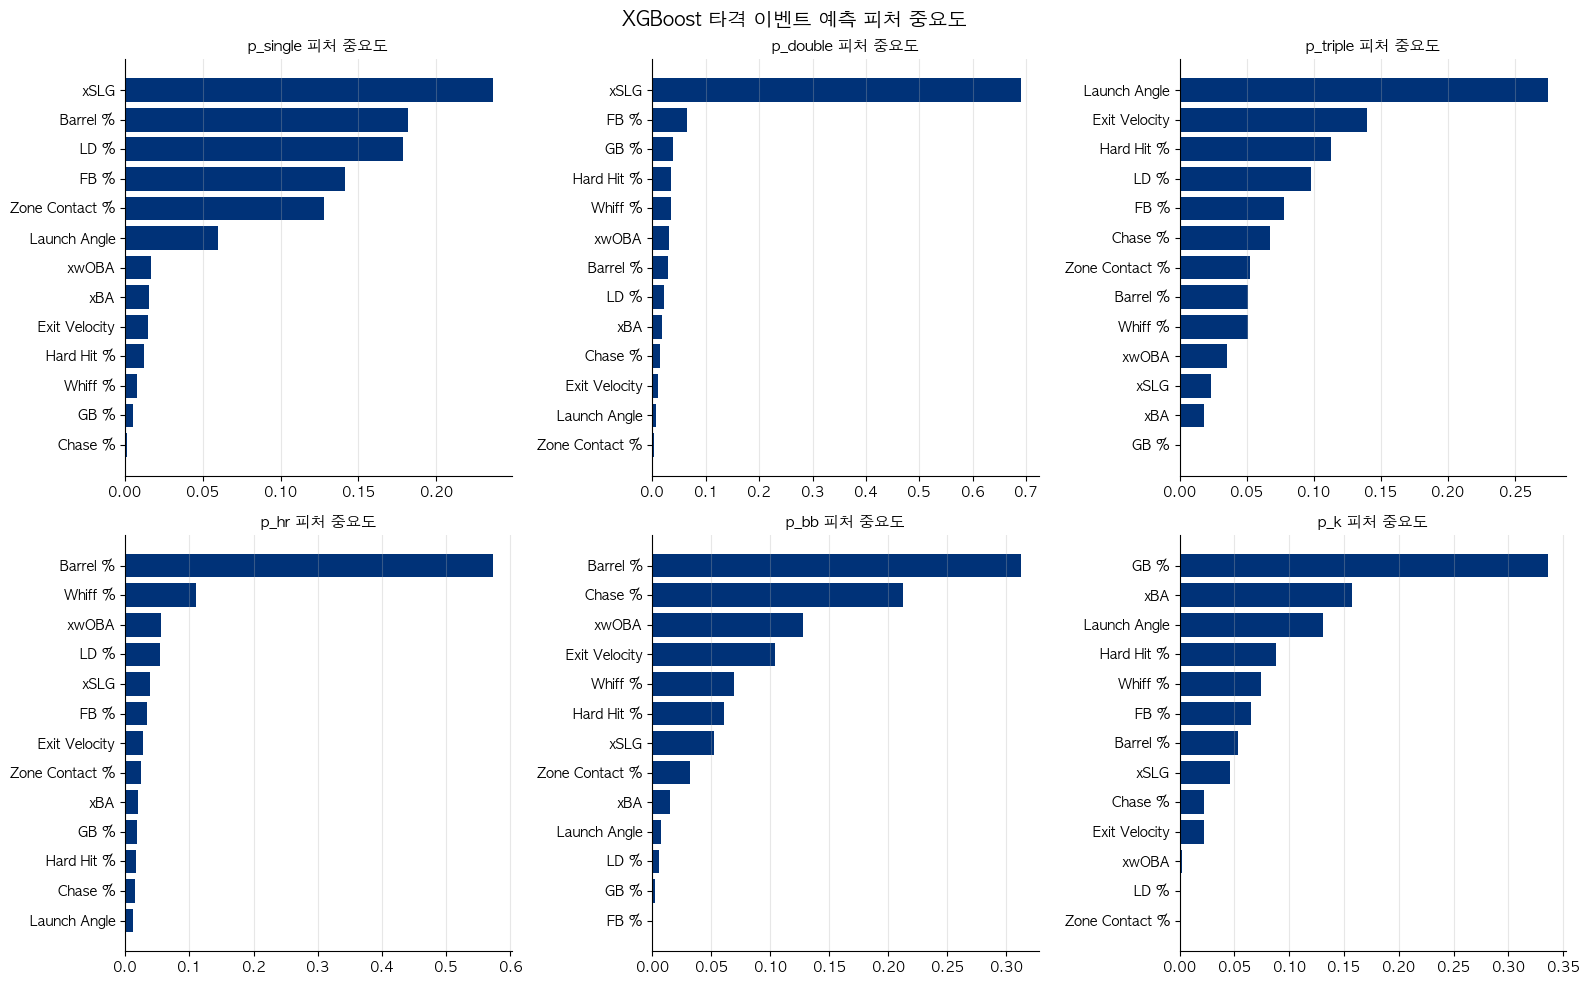


=== 기존 비율 기반 ===
시즌 시뮬 500회 결과
  평균 승: 50.0  |  중앙값: 50
  5th~95th percentile: 40 ~ 60승

=== XGBoost Hybrid ===
시즌 시뮬 500회 결과
  평균 승: 49.5  |  중앙값: 49
  5th~95th percentile: 40 ~ 59승


In [9]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 1. 피처 준비
# ============================================================
lineup = [
    "Marcus Semien",
    "Corey Seager",
    "Wyatt Langford",
    "Adolis García",
    "Jake Burger",
    "Josh Jung",
    "Jonah Heim",
    "Josh Smith",
    "Kyle Higashioka",
]

def advance_runners(runners, outs, event):
    """
    event: 'single','double','triple','hr','bb','k','out'
    returns: (new_runners, new_outs, runs_scored)
    """
    runs = 0
    r1 = bool(runners & 1)
    r2 = bool(runners & 2)
    r3 = bool(runners & 4)

    if event == 'hr':
        runs = 1 + r1 + r2 + r3
        return 0, outs, runs

    elif event == 'triple':
        runs = r1 + r2 + r3
        return 4, outs, runs

    elif event == 'double':
        runs = r2 + r3
        new_r2 = 2
        new_r3 = 4 if r1 else 0
        return new_r2 | new_r3, outs, runs

    elif event == 'single':
        runs = r2 + r3
        new_r1 = 1
        new_r2 = 2 if r1 else 0
        return new_r1 | new_r2, outs, runs

    elif event == 'bb':
        if r1 and r2 and r3:
            return 7, outs, 1
        elif r1 and r2:
            return 7, outs, 0
        elif r1:
            return 3, outs, 0
        else:
            return runners | 1, outs, 0

    elif event in ('k', 'out'):
        return runners, outs + 1, 0

    return runners, outs, 0

def simulate_inning(batter_probs_list, lineup_start):
    """
    이닝 시뮬 — lineup_start 위치부터 타순 순환
    returns: (runs_scored, next_lineup_idx)
    """
    if not batter_probs_list:
        raise ValueError("lineup_probs가 비어 있습니다. 타순 구성 셀을 먼저 실행하세요.")
    runners, outs, total_runs = 0, 0, 0
    idx = lineup_start
    n   = len(batter_probs_list)

    while outs < 3:
        probs = batter_probs_list[idx % n]
        event = np.random.choice(list(probs.keys()), p=list(probs.values()))
        runners, outs, runs = advance_runners(runners, outs, event)
        total_runs += runs
        idx += 1

    return total_runs, idx % n


def simulate_game(batter_probs_list, n_innings=9):
    """
    9이닝 경기 시뮬 — 타순이 이닝을 넘어 연속 순환
    returns: 팀 득점
    """
    total_runs = 0
    lineup_idx = 0

    for _ in range(n_innings):
        runs, lineup_idx = simulate_inning(batter_probs_list, lineup_idx)
        total_runs += runs

    return total_runs

def simulate_opponent_runs(pitcher_era=4.50, n_innings=9):
    """
    상대 득점 시뮬 — Rangers 투수 ERA 기반 Poisson 근사
    ERA 9 = 9이닝 기대 실점
    """
    expected_runs = pitcher_era * n_innings / 9
    return int(np.random.poisson(expected_runs))


def simulate_season(batter_probs_list, n_games=162,
                    team_era=4.00, n_sims=1000):
    """
    시즌 시뮬 n_sims회 반복 → 평균 승패 반환
    team_era: Rangers 투수 ERA (상대 득점 산출)
    """
    season_wins = []

    for _ in range(n_sims):
        wins = 0
        for _ in range(n_games):
            rangers_runs  = simulate_game(batter_probs_list)
            opponent_runs = simulate_opponent_runs(team_era)
            if rangers_runs > opponent_runs:
                wins += 1
        season_wins.append(wins)

    arr = np.array(season_wins)
    print(f"시즌 시뮬 {n_sims}회 결과")
    print(f"  평균 승: {arr.mean():.1f}  |  중앙값: {np.median(arr):.0f}")
    print(f"  5th~95th percentile: {np.percentile(arr, 5):.0f} ~ {np.percentile(arr, 95):.0f}승")
    return arr
hit_stat = pd.read_csv("./data/rangers_hitting_statcast.csv")

def extract_probs(row):
    """
    타자 데이터 1행 → 이벤트 확률 딕셔너리
    """
    pa        = row["PA"]
    h         = row["H"]
    double_   = row["2B"]
    triple_   = row["3B"]
    hr        = row["HR"]
    bb        = row["BB"]
    strikeout = row["SO"]

    single    = (h - double_ - triple_ - hr) / pa
    out       = max(0, 1 - (h + bb + strikeout) / pa)

    probs = {
        'single': single,
        'double': double_ / pa,
        'triple': triple_ / pa,
        'hr':     hr       / pa,
        'bb':     bb       / pa,
        'k':      strikeout / pa,
        'out':    out,
    }

    # 음수 방지 + 합계 1.0 보정
    probs = {key: max(0, val) for key, val in probs.items()}
    total = sum(probs.values())
    return {key: val / total for key, val in probs.items()}


# Rangers 주전 타순
lineup = [
    "Marcus Semien",
    "Corey Seager",
    "Wyatt Langford",
    "Adolis García",
    "Jake Burger",
    "Josh Jung",
    "Jonah Heim",
    "Josh Smith",
    "Kyle Higashioka",
]

lineup_probs = []
for name in lineup:
    row = hit_stat[hit_stat["Player"] == name]
    if row.empty:
        print(f"⚠️  {name} 데이터 없음")
        continue
    lineup_probs.append(extract_probs(row.iloc[0]))

print(f"타순 구성: {len(lineup_probs)}명")
for name, probs in zip(lineup, lineup_probs):
    print(f"  {name:<22}  HR={probs['hr']:.3f}  BB={probs['bb']:.3f}  K={probs['k']:.3f}")


def build_features(hit_stat, hit_dis, hit_bat):
    """
    3개 테이블 병합 → XGBoost 피처 생성
    """
    df = hit_stat.merge(hit_dis, on="Player", how="left")
    df = df.merge(hit_bat[["Player","GB %","FB %","LD %"]], on="Player", how="left")

    features = [
        "xBA", "xSLG", "xwOBA",          # 기대 지표
        "Barrel %", "Hard Hit %",          # 파워
        "Exit Velocity", "Launch Angle",   # 타구 질
        "Chase %", "Whiff %",              # 선구안
        "Zone Contact %",                  # 컨택
        "GB %", "FB %", "LD %",            # 타구 방향
    ]

    # 실제 타격 결과 (타깃)
    targets = {
        "p_single": lambda r: (r["H"] - r["2B"] - r["3B"] - r["HR"]) / r["PA"],
        "p_double": lambda r: r["2B"] / r["PA"],
        "p_triple": lambda r: r["3B"] / r["PA"],
        "p_hr":     lambda r: r["HR"] / r["PA"],
        "p_bb":     lambda r: r["BB"] / r["PA"],
        "p_k":      lambda r: r["SO"] / r["PA"],
    }

    for name, func in targets.items():
        df[name] = df.apply(func, axis=1)

    return df, features, list(targets.keys())


# ============================================================
# 2. XGBoost 모델 학습
#    Rangers 데이터만으로는 샘플 부족 → all_team_wrc+ 등
#    지금은 Rangers 내부 cross-validation으로 검증
# ============================================================

def train_xgb_models(df, features, target_cols):
    """
    타깃별 XGBoost 모델 학습
    returns: models dict, scaler
    """
    from sklearn.model_selection import cross_val_score

    X = df[features].dropna()
    idx = X.index

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    models = {}
    for col in target_cols:
        y = df.loc[idx, col].values
        model = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=42,
            verbosity=0
        )
        model.fit(X_scaled, y)
        models[col] = model
        print(f"  {col} 학습 완료")

    return models, scaler, features


# ============================================================
# 3. XGBoost로 확률 예측 → Markov Chain에 주입
# ============================================================

def extract_probs_xgb(row, models, scaler, features):
    """
    XGBoost 모델로 이벤트 확률 예측
    기존 extract_probs() 대체
    """
    X = pd.DataFrame([row[features]])[features]

    # NaN 처리
    X = X.fillna(X.mean())
    X_scaled = scaler.transform(X)

    probs = {}
    for event, model in models.items():
        key = event.replace("p_", "")
        key = "hr" if key == "hr" else key
        probs[key] = max(0, float(model.predict(X_scaled)[0]))

    # out 확률 = 나머지
    probs["out"] = max(0, 1 - sum(probs.values()))

    # 합계 1.0 보정
    total = sum(probs.values())
    return {k: v/total for k, v in probs.items()}


# ============================================================
# 4. 피처 중요도 시각화
# ============================================================

def plot_feature_importance(models, features):
    import matplotlib.pyplot as plt

    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (target, model) in zip(axes, models.items()):
        importance = model.feature_importances_
        sorted_idx = np.argsort(importance)
        ax.barh([features[i] for i in sorted_idx],
                importance[sorted_idx],
                color="#003278")
        ax.set_title(f"{target} 피처 중요도", fontsize=11)
        ax.grid(axis="x", alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

    plt.suptitle("XGBoost 타격 이벤트 예측 피처 중요도",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 실행
# ============================================================

hit_stat = pd.read_csv("./data/rangers_hitting_statcast.csv")
hit_dis  = pd.read_csv("./data/rangers_hitting_discipline.csv")
hit_bat  = pd.read_csv("./data/rangers_hitting_batted.csv")

# Rangers + MLB 행 제거
hit_stat = hit_stat[~hit_stat["Player"].isin(["Rangers", "MLB"])]
hit_dis  = hit_dis[~hit_dis["Player"].isin(["Rangers", "MLB"])]
hit_bat  = hit_bat[~hit_bat["Player"].isin(["Rangers", "MLB"])]

print("피처 준비 중...")
df_feat, features, target_cols = build_features(hit_stat, hit_dis, hit_bat)

print("XGBoost 학습 중...")
models, scaler, features = train_xgb_models(df_feat, features, target_cols)

# 타순 확률 재추출 (XGBoost 버전)
print("\nXGBoost 기반 타자 확률:")
lineup_probs_xgb = []
for name in lineup:
    row = df_feat[df_feat["Player"] == name]
    if row.empty:
        print(f"⚠️ {name} 없음")
        continue
    probs = extract_probs_xgb(row.iloc[0], models, scaler, features)
    lineup_probs_xgb.append(probs)
    print(f"  {name:<22} HR={probs['hr']:.3f} BB={probs['bb']:.3f} K={probs['k']:.3f}")

# 피처 중요도 시각화
plot_feature_importance(models, features)

# 기존 시뮬과 비교
print("\n=== 기존 비율 기반 ===")
arr_old = simulate_season(lineup_probs, team_era=4.80, n_sims=500)

print("\n=== XGBoost Hybrid ===")
arr_xgb = simulate_season(lineup_probs_xgb, team_era=4.80, n_sims=500)

 - Rangers 22명 데이터만으로 학습했기 때문에 XGBoost가 사실상 원래 값을 그대로 학습 
 - 샘플이 너무 작아서 일반화가 안 된 상태임. 

### 방향 1: 데이터 확장 (샘플 늘리기)
    → all_team_wrc+.csv 활용
    → 전체 MLB 타자 데이터로 학습
    → Rangers 타자 예측에 활용

### 방향 2: 현재 구조 유지하고 LSTM으로 넘어가기
    → 월별 게임로그 데이터 있으니까
    → 성적 시계열 예측으로 확장